In [7]:
%%writefile extraccion_pleyades.sh
#!/bin/bash
echo "=================================================="
echo " 🚀 Iniciando Pipeline de Extracción de Datos"
echo "=================================================="

# 1. Definimos la consulta ADQL pura (sin preocuparnos por espacios o símbolos especiales)
ADQL="SELECT RA_ICRS, DE_ICRS, pmRA, pmDE, Gmag, BPmag, RPmag FROM \"I/355/gaiadr3\" WHERE Gmag < 15 AND 1=CONTAINS(POINT('ICRS', RA_ICRS, DE_ICRS), CIRCLE('ICRS', 56.75, 24.11, 1.5))"

# 2. Endpoint base de VizieR (limpio, sin parámetros pegados)
TAP_URL="https://tapvizier.cds.unistra.fr/TAPVizieR/tap/sync"

# 3. Descargamos usando cURL con el método POST.
# --data-urlencode codifica matemáticamente la consulta para que el servidor no la rechace.
echo "📡 Conectando con el servidor TAP de VizieR..."
curl -s -X POST \
     -d "request=doQuery" \
     -d "lang=ADQL" \
     -d "format=csv" \
     --data-urlencode "query=${ADQL}" \
     "${TAP_URL}" -o pleyades_bruto.csv

echo "✅ Descarga completada: pleyades_bruto.csv"
echo "Cantidad de datos descargados: "
cat pleyades_bruto.csv | wc -l
echo "=================================================="

Overwriting extraccion_pleyades.sh


In [8]:
!bash extraccion_pleyades.sh

 🚀 Iniciando Pipeline de Extracción de Datos
📡 Conectando con el servidor TAP de VizieR...
✅ Descarga completada: pleyades_bruto.csv
Cantidad de datos descargados: 
3508


In [3]:
import pandas as pd

# 1. Cargar el archivo generado por Bash
df = pd.read_csv('pleyades_bruto.csv')

# 2. Limpieza vital: Eliminar filas donde el telescopio falló en medir el movimiento (NaN)
df_limpio = df.dropna(subset=['pmRA', 'pmDE', 'BPmag', 'RPmag'])

print(f"Estrellas totales descargadas: {len(df)}")
print(f"Estrellas con datos completos: {len(df_limpio)}")

# 3. Ingeniería de Datos: Calculamos el Índice de Color
df_limpio['Color'] = df_limpio['BPmag'] - df_limpio['RPmag']

Estrellas totales descargadas: 3507
Estrellas con datos completos: 3438


/tmp/ipykernel_7312/3342573678.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio['Color'] = df_limpio['BPmag'] - df_limpio['RPmag']


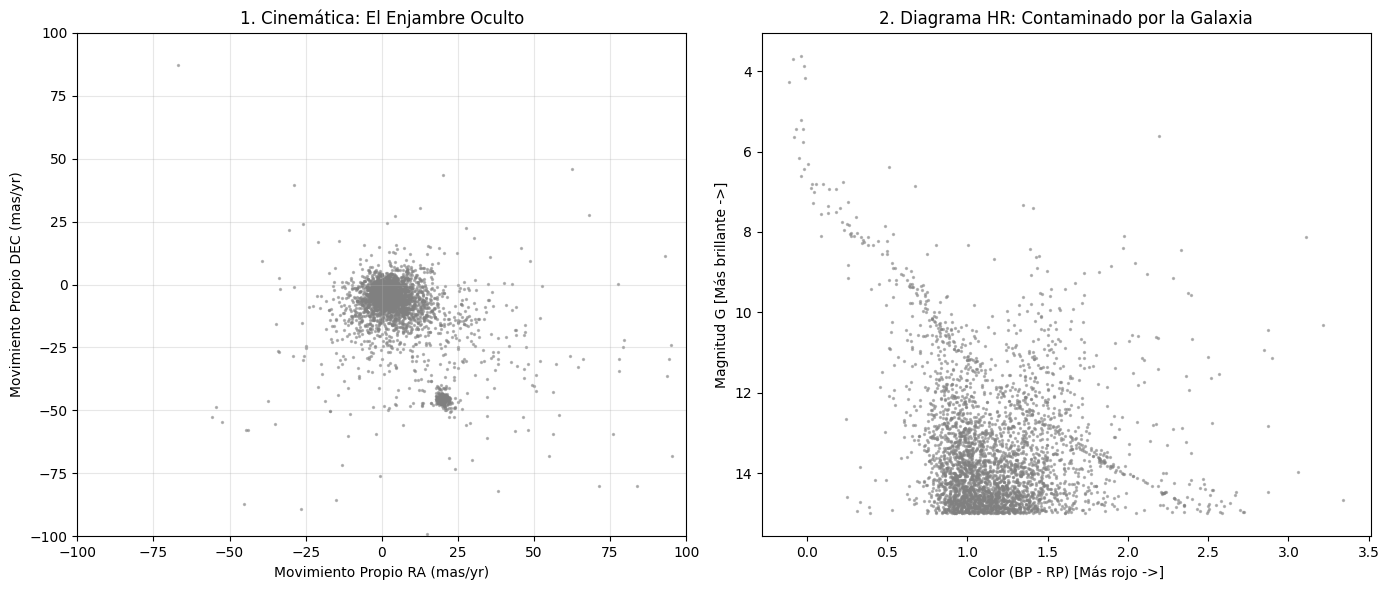

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICO 1: Cinemática (Movimiento Propio) ---
# Aquí veremos hacia dónde se mueve cada estrella
ax1.scatter(df_limpio['pmRA'], df_limpio['pmDE'], s=2, color='gray', alpha=0.5)
ax1.set_title('1. Cinemática: El Enjambre Oculto')
ax1.set_xlabel('Movimiento Propio RA (mas/yr)')
ax1.set_ylabel('Movimiento Propio DEC (mas/yr)')
ax1.set_xlim(-100, 100)
ax1.set_ylim(-100, 100)
ax1.grid(True, alpha=0.3)

# --- GRÁFICO 2: Diagrama Color-Magnitud (Contaminado) ---
ax2.scatter(df_limpio['Color'], df_limpio['Gmag'], s=2, color='gray', alpha=0.5)
ax2.invert_yaxis() # Convención astronómica
ax2.set_title('2. Diagrama HR: Contaminado por la Galaxia')
ax2.set_xlabel('Color (BP - RP) [Más rojo ->]')
ax2.set_ylabel('Magnitud G [Más brillante ->]')

plt.tight_layout()
plt.show()

Miembros reales de las Pléyades encontrados: 303


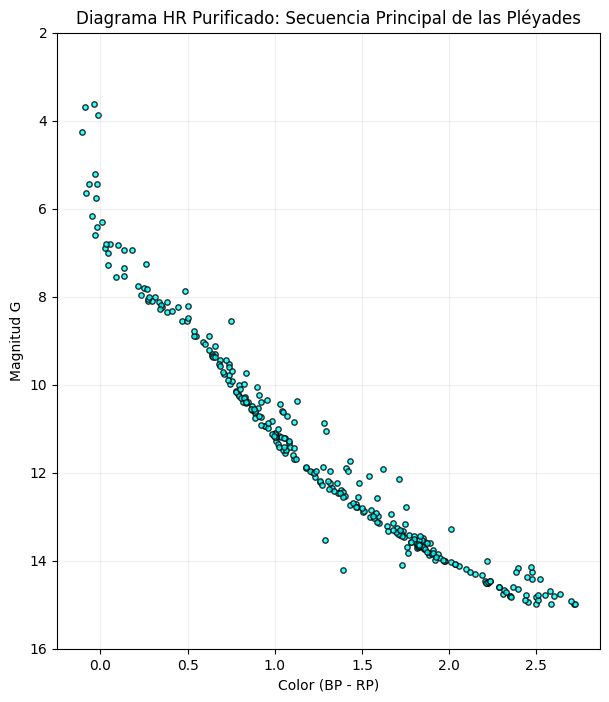

In [5]:
# Filtramos la "mancha" densa observada en el gráfico anterior
condicion_ra = (df_limpio['pmRA'] > 15) & (df_limpio['pmRA'] < 25)
condicion_dec = (df_limpio['pmDE'] > -50) & (df_limpio['pmDE'] < -40)

# Aplicamos el filtro para crear un nuevo DataFrame solo con los miembros del cúmulo
df_pleyades = df_limpio[condicion_ra & condicion_dec]

print(f"Miembros reales de las Pléyades encontrados: {len(df_pleyades)}")

# --- GRÁFICO FINAL: El Diagrama Limpio ---
plt.figure(figsize=(7, 8))
plt.scatter(df_pleyades['Color'], df_pleyades['Gmag'], s=15, color='cyan', edgecolor='black', alpha=0.8)
plt.ylim(16,2)

plt.title('Diagrama HR Purificado: Secuencia Principal de las Pléyades')
plt.xlabel('Color (BP - RP)')
plt.ylabel('Magnitud G')
plt.grid(True, alpha=0.2)
plt.show()

```bash
%%bash
# Creamos un archivo de requisitos (buenas prácticas en Python)
echo "pandas" > requirements.txt
echo "matplotlib" >> requirements.txt
echo "seaborn" >> requirements.txt

# Inicializamos Git
git init -q
git config --global user.email "estudiante@astronomia.com"
git config --global user.name "Astro Estudiante"

# Añadimos los archivos que hemos creado
git add extraccion_pleyades.sh requirements.txt pleyades_bruto.csv

# Guardamos la versión
git commit -m "Pipeline inicial: Extracción ADQL y datos brutos de M45"

echo "¡Repositorio local actualizado con éxito!"
git log --oneline
```

In [1]:
dict1 = {'nombre': ['Juan','Pedro'], 'edad': [25,12], 'ciudad': ['Madrid','Medel']}


In [7]:
for kk in dict1:
  print(dict1[kk][1])

Pedro
12
Medel
